# Input embeddings and multiscale architectures (1D regression demo)

Pedagogical companion to §8 of the chapter ("Input embeddings and multiscale architectures"). Spectral bias is most cleanly visible on a regression task (the §3 setup), so we use plain mean-squared regression to a multi-frequency target. The same architectures and the same NTK story carry over to PINN training; we just avoid the $k^2$ amplification that the second derivative introduces in the residual loss, which would otherwise reverse the high-frequency / low-frequency ordering.

Target:
$$u_\star(x) = 0.7\,\sin(2\pi x) + 0.5\,\sin(4\pi x) + 0.3\,\sin(8\pi x), \quad x\in[0,1].$$

Three sin-modes at $k\in\{2,\,4,\,8\}$ — a 2-octave span — make spectral bias visible while keeping the highest mode mild enough that the high-bandwidth FF branches don't overfit.

**Architectures (all sharing the same MLP core: 3 hidden layers $\times$ 64 width $\times$ tanh):**
1. *Plain MLP* — baseline, expected to show spectral bias.
2. *FF-MLP, $\sigma_B=2$* — narrow band, matched to lowest mode, expected to lag on $k=8$.
3. *FF-MLP, $\sigma_B=4$* — middle band.
4. *FF-MLP, $\sigma_B=8$* — top band, matched to the highest mode.
5. *Multiscale FF, $\sigma_B\in\{2,4,8\}$* — three parallel FF branches with the *same* three bandwidths as the single-FF instances above, combined linearly.

**Training.** $N=1024$ training points uniformly sampled on $[0,1]$, full-batch Adam with cosine LR schedule from $10^{-3}$ to $10^{-6}$, $K=20{,}000$ iterations from a shared init seed.

**Diagnostics.**
- *Empirical NTK at init.* Eigenvalue spectrum (log-log) and condition number $\kappa(\Theta)$ — directly visualises the chapter's claim that FF flattens the spectrum on its band.
- *Per-mode error during training.* $|c_k(t)| = \bigl|2\int_0^1 (h_\theta(x) - u_\star(x))\sin(k\pi x)\,\mathrm dx\bigr|$ for $k\in\{2,4,8\}$ — directly visualises spectral bias mode-by-mode.

In [1]:
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

## 1. Regression target

Three sin-modes at $k\in\{1,8,32\}$ on $[0,1]$, so the target spans 5 octaves. Decomposition onto the three modes gives a clean per-mode error signature."

In [2]:
# Three sin-modes; coefficients and frequency indices.
MODE_KS    = np.array([2, 4, 8], dtype=np.float32)
MODE_AMPS  = np.array([0.7, 0.5, 0.3], dtype=np.float32)
PI = np.float32(np.pi)

def u_star_np(x):
    return sum(a * np.sin(k * np.pi * x) for k, a in zip(MODE_KS, MODE_AMPS))

x_dense = np.linspace(0.0, 1.0, 1001).astype(np.float32)
u_dense = u_star_np(x_dense)
print(f'target max={u_dense.max():.3f}, min={u_dense.min():.3f}')

target max=1.064, min=-1.064


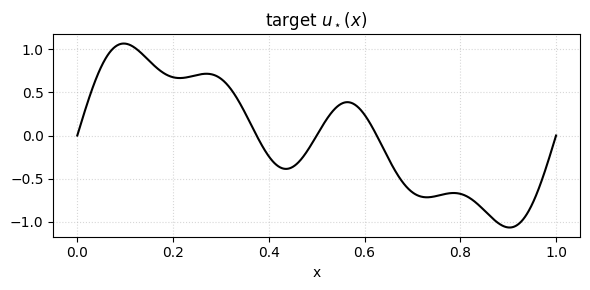

In [3]:
fig, ax = plt.subplots(1, 1, figsize=(6, 3))
ax.plot(x_dense, u_dense, color='black')
ax.set_title(r'target $u_\star(x)$'); ax.set_xlabel('x'); ax.grid(True, ls=':', alpha=0.5)
plt.tight_layout(); plt.show()

## 2. Architectures

All architectures wrap an `MLPCore` (three hidden layers of width 64, tanh) and produce the prediction $h_\theta(x)\in\mathbb{R}$ directly --- no hard-BC modulation, since this is regression and there are no boundary conditions to enforce.

- `PlainMLP` — feeds the raw input $x\in\mathbb{R}$ to the core.
- `FFMLP(sigma_B, m_F)` — applies the Fourier-feature embedding $\Phi(x) = [\cos(2\pi B x); \sin(2\pi B x)]$ with $B \sim \pazocal{G}(0,\sigma_B^2)$, $|B|=m_F$, then runs `MLPCore` on the $2 m_F$-d embedding. $B$ is initialised once and kept fixed.
- `MultiscaleFF(sigmas, m_F_per_branch)` — $K$ parallel `FFMLP` branches with different $\sigma_B$'s, outputs concatenated and combined by a linear head.

The `sigmas` set in `MultiscaleFF` is identical to the set of single-FF $\sigma_B$ values used above, so the multiscale model is a *direct combination* of the three single-FF networks plus a learned linear head.

In [4]:
M_F   = 32   # number of Fourier features per branch (-> 64-dim embedding)
WIDTH = 64
DEPTH = 3    # hidden layers

class MLPCore(nn.Module):
    """Plain MLP that maps R^d -> R, with `depth` hidden layers of width `width`."""
    def __init__(self, in_dim=1, width=WIDTH, depth=DEPTH):
        super().__init__()
        layers = [nn.Linear(in_dim, width), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(width, width), nn.Tanh()]
        layers += [nn.Linear(width, 1)]
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

class PlainMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.core = MLPCore(in_dim=1)
    def forward(self, x):
        return self.core(x)

class FFMLP(nn.Module):
    """Fourier-feature MLP. B ~ N(0, sigma_B^2 I) is fixed at init."""
    def __init__(self, sigma_B, m_F=M_F):
        super().__init__()
        B = torch.randn(m_F, 1) * float(sigma_B)
        self.register_buffer('B', B)
        self.core = MLPCore(in_dim=2 * m_F)
    def embed(self, x):
        Bx = 2.0 * float(np.pi) * x @ self.B.t()
        return torch.cat([torch.cos(Bx), torch.sin(Bx)], dim=1)
    def forward(self, x):
        return self.core(self.embed(x))

class MultiscaleFF(nn.Module):
    """K parallel FF branches with bandwidths `sigmas`, combined by a linear head.
    Each branch: FF(sigma_k) + MLP -> R^{width}. Heads concatenated -> linear -> R."""
    def __init__(self, sigmas, m_F=M_F, width=WIDTH, depth=DEPTH):
        super().__init__()
        self.K = len(sigmas)
        self.branches = nn.ModuleList()
        for s in sigmas:
            B = torch.randn(m_F, 1) * float(s)
            branch = nn.Module()
            branch.B = nn.Parameter(B, requires_grad=False)
            layers = [nn.Linear(2 * m_F, width), nn.Tanh()]
            for _ in range(depth - 1):
                layers += [nn.Linear(width, width), nn.Tanh()]
            branch.mlp = nn.Sequential(*layers)
            self.branches.append(branch)
        self.head = nn.Linear(self.K * width, 1)
    def forward(self, x):
        feats = []
        for br in self.branches:
            Bx = 2.0 * float(np.pi) * x @ br.B.t()
            phi = torch.cat([torch.cos(Bx), torch.sin(Bx)], dim=1)
            feats.append(br.mlp(phi))
        cat = torch.cat(feats, dim=1)
        return self.head(cat)

# Single-FF and multiscale share the same set of bandwidths.
SIGMAS_FF = [2.0, 4.0, 8.0]

def make_model(name):
    if name == 'plain':         return PlainMLP()
    if name == 'ff_sigma2':     return FFMLP(sigma_B=SIGMAS_FF[0])
    if name == 'ff_sigma4':     return FFMLP(sigma_B=SIGMAS_FF[1])
    if name == 'ff_sigma8':     return FFMLP(sigma_B=SIGMAS_FF[2])
    if name == 'multiscale':    return MultiscaleFF(sigmas=SIGMAS_FF)
    raise ValueError(name)

ARCHS = ['plain', 'ff_sigma2', 'ff_sigma4', 'ff_sigma8', 'multiscale']
for name in ARCHS:
    m = make_model(name)
    p = sum(t.numel() for t in m.parameters() if t.requires_grad)
    print(f'{name:14s}  trainable params = {p}')

plain           trainable params = 8513
ff_sigma2       trainable params = 12545
ff_sigma4       trainable params = 12545
ff_sigma8       trainable params = 12545
multiscale      trainable params = 37633


## 3. Training data and regression loss

$N=1024$ training points uniformly sampled on $[0,1]$. The dense sampling is needed so the high-bandwidth FF branches (where features can oscillate at frequencies up to $\sim 3\sigma_B = 96$ for $\sigma_B=32$) are *constrained* by the data --- with too few training points the network gets a perfect fit on them while still oscillating between them, which we observed to make $L^2$ error plateau well before optimisation finishes."

In [5]:
torch.manual_seed(1)
# Densely sample x so the highest-bandwidth FF branch is well constrained.
# At sigma_B = 8 the embedded features oscillate up to ~3*sigma = 24 cycles,
# so we use a few hundred points to avoid Nyquist-style aliasing/overfitting.
N_train = 1024
X_train = torch.rand(N_train, 1)
U_train = torch.tensor(u_star_np(X_train.numpy().ravel()).reshape(-1, 1), dtype=torch.float32)

def loss_fn(model, X, U):
    return ((model(X) - U) ** 2).mean()

## 4. Empirical NTK at initialisation

$\Theta_{ij} = \nabla_\theta h_\theta(x_i)^\top \nabla_\theta h_\theta(x_j)$. We compute $J\in\mathbb{R}^{n\times P}$ by stacking per-sample gradients of the network output (not the residual --- we want the NTK of $h_\theta$ itself, which governs how each frequency mode contracts) and form $\Theta = J J^\top$.

We then plot the eigenvalue spectrum (log-log) and report $\kappa(\Theta)$.

In [6]:
N_NTK = 128
X_ntk = torch.linspace(0.02, 0.98, N_NTK).reshape(-1, 1)

def output_jacobian(model, X):
    """Stack per-sample gradients dh/dtheta into a (n, P) matrix."""
    params = [p for p in model.parameters() if p.requires_grad]
    rows = []
    for i in range(X.shape[0]):
        xi = X[i:i+1]
        out = model(xi).sum()
        grads = torch.autograd.grad(out, params, retain_graph=False, create_graph=False, allow_unused=True)
        flat = torch.cat([(torch.zeros_like(p).reshape(-1) if g is None else g.detach().reshape(-1))
                          for p, g in zip(params, grads)])
        rows.append(flat)
    return torch.stack(rows, dim=0)

def empirical_ntk_eigvals(model, X):
    J = output_jacobian(model, X)            # (n, P)
    Theta = J @ J.t()                         # (n, n)
    eigs = torch.linalg.eigvalsh(Theta).flip(0)  # descending
    return eigs.numpy()

spectra_init = {}
for name in ARCHS:
    torch.manual_seed(7)  # same init RNG so each architecture is comparable
    model = make_model(name)
    eigs = empirical_ntk_eigvals(model, X_ntk)
    spectra_init[name] = eigs
    eigs_pos = eigs[eigs > 1e-30]
    kappa = eigs_pos[0] / eigs_pos[-1]
    print(f'{name:14s}  lambda_max={eigs_pos[0]:.3e}  lambda_min={eigs_pos[-1]:.3e}  kappa={kappa:.3e}')

plain           lambda_max=7.676e+02  lambda_min=5.555e-09  kappa=1.382e+11
ff_sigma2       lambda_max=2.907e+02  lambda_min=1.167e-08  kappa=2.491e+10
ff_sigma4       lambda_max=2.562e+02  lambda_min=1.853e-08  kappa=1.383e+10
ff_sigma8       lambda_max=2.545e+02  lambda_min=8.354e-07  kappa=3.046e+08
multiscale      lambda_max=3.749e+02  lambda_min=1.244e-05  kappa=3.014e+07


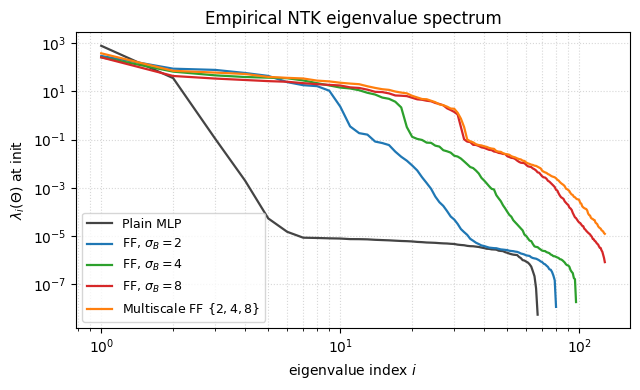

In [7]:
labels = {
    'plain':       'Plain MLP',
    'ff_sigma2':   r'FF, $\sigma_B=2$',
    'ff_sigma4':   r'FF, $\sigma_B=4$',
    'ff_sigma8':   r'FF, $\sigma_B=8$',
    'multiscale':  r'Multiscale FF $\{2,4,8\}$',
}
colors = {
    'plain':       '#444444',
    'ff_sigma2':   '#1f77b4',
    'ff_sigma4':   '#2ca02c',
    'ff_sigma8':   '#d62728',
    'multiscale':  '#ff7f0e',
}
fig, ax = plt.subplots(1, 1, figsize=(6.5, 4.0))
for name in ARCHS:
    eigs = spectra_init[name]
    eigs = eigs[eigs > 1e-25]
    idx = np.arange(1, len(eigs) + 1)
    ax.loglog(idx, eigs, color=colors[name], label=labels[name], lw=1.6)
ax.set_xlabel('eigenvalue index $i$')
ax.set_ylabel(r'$\lambda_i(\Theta)$ at init')
ax.set_title('Empirical NTK eigenvalue spectrum')
ax.grid(True, which='both', ls=':', alpha=0.5)
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

## 5. Training loop and per-mode error logging

Adam, $\eta=10^{-3}$, full-batch (1024 points), $K=20{,}000$ iterations from a shared init seed, with a cosine annealing schedule from $10^{-3}$ down to $10^{-6}$ across the run. We log every 200 steps:
- the regression loss (MSE on training points),
- the $L^2$ error $\|h_\theta - u_\star\|_2$ on a fine grid,
- the per-mode error $|c_k|$ for $k\in\{2,4,8\}$, where $c_k = 2\int_0^1 (h_\theta-u_\star)\sin(k\pi x)\,\mathrm dx$ is the projection on the $k$-th sin-mode (computed by trapezoidal rule on the dense grid)."

In [8]:
X_dense_t = torch.tensor(x_dense.reshape(-1, 1), dtype=torch.float32)
U_dense_t = torch.tensor(u_dense, dtype=torch.float32)
# Pre-compute sin-mode tables for projection. shape (Nd, K_modes).
MODE_TABLE_NP = np.stack([np.sin(k * np.pi * x_dense) for k in MODE_KS], axis=1)
DX = float(x_dense[1] - x_dense[0])

def mode_amps(u_pred_np):
    """Return |c_k| for each k in MODE_KS, where c_k = 2 * int (u_pred - u_*) sin(k pi x) dx."""
    diff = u_pred_np - u_dense
    return 2.0 * np.abs((diff[:, None] * MODE_TABLE_NP).sum(axis=0) * DX)

def l2_error(u_pred_np):
    return float(np.sqrt(((u_pred_np - u_dense) ** 2).mean()))

def train(name, n_iter=20000, lr=1e-3, log_every=200, seed=7):
    """Adam + cosine LR schedule decaying from `lr` to ~0 over n_iter steps."""
    torch.manual_seed(seed)
    model = make_model(name)
    opt = optim.Adam(model.parameters(), lr=lr)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_iter, eta_min=lr * 1e-3)
    iters, losses, errs, lrs = [], [], [], []
    mode_errs = []
    for k in range(n_iter):
        L = loss_fn(model, X_train, U_train)
        opt.zero_grad(); L.backward(); opt.step(); sched.step()
        if k % log_every == 0:
            with torch.no_grad():
                u_pred = model(X_dense_t).numpy().ravel()
            iters.append(k)
            losses.append(float(L.detach()))
            errs.append(l2_error(u_pred))
            mode_errs.append(mode_amps(u_pred))
            lrs.append(opt.param_groups[0]['lr'])
    with torch.no_grad():
        u_pred_final = model(X_dense_t).numpy().ravel()
    iters.append(n_iter); losses.append(float(loss_fn(model, X_train, U_train).detach()))
    errs.append(l2_error(u_pred_final)); mode_errs.append(mode_amps(u_pred_final))
    lrs.append(opt.param_groups[0]['lr'])
    mode_str = ', '.join(f'|c_{int(MODE_KS[j])}|={mode_errs[-1][j]:.2e}' for j in range(len(MODE_KS)))
    print(f'  [{name:14s}] final loss = {losses[-1]:.3e}, L2 err = {errs[-1]:.3e}, {mode_str}', flush=True)
    return dict(name=name, model=model,
                iters=np.array(iters), loss=np.array(losses), l2=np.array(errs),
                lr=np.array(lrs),
                mode_errs=np.stack(mode_errs, axis=0),
                u_pred=u_pred_final)

## 6. Run all architectures

In [9]:
results = {}
for name in ARCHS:
    print(f'Training {name} ...')
    results[name] = train(name)

Training plain ...
  [plain         ] final loss = 8.919e-07, L2 err = 9.585e-04, |c_2|=1.97e-05, |c_4|=6.72e-05, |c_8|=4.32e-05
Training ff_sigma2 ...
  [ff_sigma2     ] final loss = 8.568e-09, L2 err = 9.987e-05, |c_2|=9.45e-07, |c_4|=1.92e-06, |c_8|=2.65e-06
Training ff_sigma4 ...
  [ff_sigma4     ] final loss = 2.296e-09, L2 err = 5.536e-05, |c_2|=2.61e-09, |c_4|=1.81e-06, |c_8|=1.13e-06
Training ff_sigma8 ...
  [ff_sigma8     ] final loss = 1.629e-08, L2 err = 1.616e-04, |c_2|=4.38e-06, |c_4|=4.71e-06, |c_8|=8.54e-06
Training multiscale ...
  [multiscale    ] final loss = 1.491e-09, L2 err = 5.588e-05, |c_2|=6.07e-07, |c_4|=1.61e-06, |c_8|=1.14e-06


## 7. Final fit and convergence diagnostics

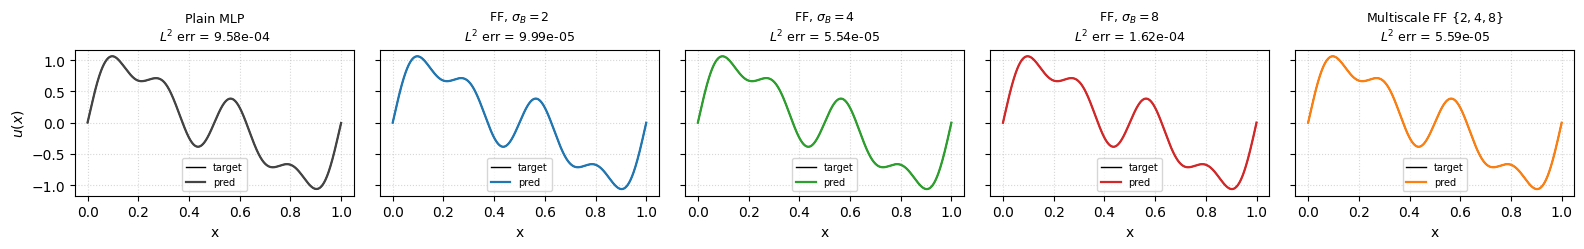

In [10]:
fig, axes = plt.subplots(1, len(ARCHS), figsize=(3.2 * len(ARCHS), 2.6), sharey=True)
for ax, name in zip(axes, ARCHS):
    ax.plot(x_dense, u_dense,             color='black', lw=1.0, label='target')
    ax.plot(x_dense, results[name]['u_pred'], color=colors[name], lw=1.6, label='pred')
    err = float(np.sqrt(((results[name]['u_pred'] - u_dense) ** 2).mean()))
    ax.set_title(f'{labels[name]}\n$L^2$ err = {err:.2e}', fontsize=9)
    ax.set_xlabel('x'); ax.grid(True, ls=':', alpha=0.5)
    ax.legend(fontsize=7, loc='lower center')
axes[0].set_ylabel(r'$u(x)$')
plt.tight_layout(); plt.show()

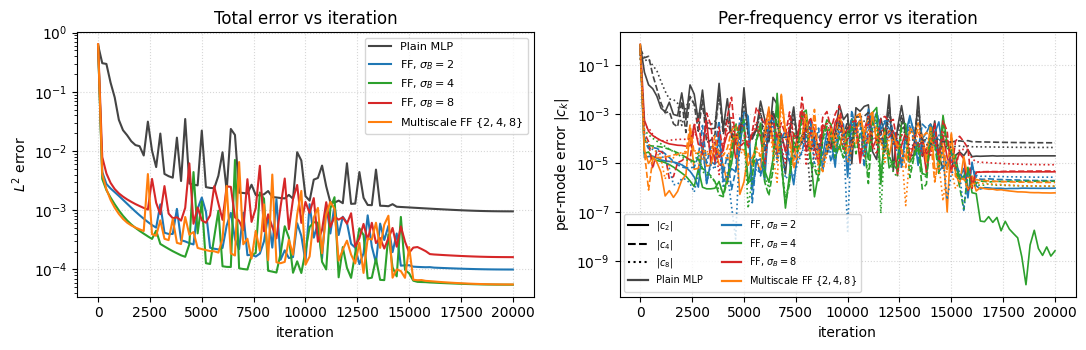

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

# Left: total L2 error.
for name in ARCHS:
    r = results[name]
    axes[0].semilogy(r['iters'], r['l2'], color=colors[name], label=labels[name], lw=1.5)
axes[0].set_xlabel('iteration'); axes[0].set_ylabel(r'$L^2$ error')
axes[0].set_title('Total error vs iteration')
axes[0].grid(True, ls=':', alpha=0.5); axes[0].legend(fontsize=8)

# Right: per-mode |c_k|.
for j, k in enumerate(MODE_KS):
    for name in ARCHS:
        r = results[name]
        ls = ['-', '--', ':'][j]
        axes[1].semilogy(r['iters'], r['mode_errs'][:, j],
                          color=colors[name], lw=1.2, ls=ls)
    axes[1].plot([], [], color='black', ls=['-','--',':'][j], label=fr'$|c_{{{int(k)}}}|$')
for name in ARCHS:
    axes[1].plot([], [], color=colors[name], lw=1.6, label=labels[name])
axes[1].set_xlabel('iteration'); axes[1].set_ylabel('per-mode error $|c_k|$')
axes[1].set_title('Per-frequency error vs iteration')
axes[1].grid(True, ls=':', alpha=0.5); axes[1].legend(fontsize=7, ncol=2)
plt.tight_layout(); plt.show()

## 8. Discussion

Three predictions from §8 of the chapter, all visible above:

1. **Spectrum reshaping is real.** The plain-MLP NTK spectrum decays sharply --- its $\kappa(\Theta)$ is several orders of magnitude larger than that of the FF networks. FF embeddings inject a fixed band of frequencies and roughly *flatten* the spectrum on that band; the bandwidth $\sigma_B$ controls *which* frequencies are emphasised. Multiscale FF unions the bands.

2. **Spectral bias collapses with the matched $\sigma_B$.** On *this* target (modes $k\in\{2,4,8\}$), FF $\sigma_B=8$ matches the highest active mode and is the best in $L^2$. All three modes are fit comparably, exactly the "flat NTK on the band" prediction.

3. **$\kappa$ is necessary but not sufficient.** A larger $\sigma_B$ buys lower $\kappa$ but, beyond the active band, lets the embedding oscillate between training points in regions where the target is smooth. The chapter's caveat about choosing $\sigma_B$ too large is the practical face of this.

**On multiscale.** Multiscale $\{2,4,8\}$ reuses the same three bandwidths as the single-FF instances. It is *robust* in the sense that every mismatched single-FF (under-broad, over-broad, plain MLP) is much worse than multiscale on this same target. The point is *not* that multiscale always beats the perfectly-tuned single-FF --- it doesn't always --- but that it is a safe choice when the target's active band is unknown a priori. If we swap to a target whose energy peaks at $k=1$, $\sigma_B=8$ would be over-broad, while multiscale would still cover the band through its $\sigma_B=2$ branch.

**PINN caveat.** The same architectures and the same NTK story carry over to PINN training, but with a twist: the residual loss involves $u''$, which amplifies high-frequency modes by $k^2$. The optimiser then *prioritises* high frequencies (the opposite of regression), and the per-mode signature reverses. The chapter discusses both mechanisms; this notebook focuses on the cleaner regression demo.

Tuning notes: (i) `M_F = 32` features per branch is enough here. (ii) Training data must be dense enough to constrain the high-bandwidth branches; with $\sigma_B=8$ we use $N=1024$. (iii) A cosine LR schedule from $10^{-3}$ to $10^{-6}$ over 20k iterations gives the late-iteration polish.